# Mislabeled-Only Cleaning — No SMOTE + Chi-Square Selection

**Objective:** Address reviewer concern about removing genuinely ambiguous samples.  
Remove ONLY the 147 likely mislabeled samples; retain all 54 genuinely ambiguous ones.

**Pipeline:**
1. Load `spambase.data` → deduplicate → 4,210 rows
2. Identify hard samples via 10-fold CV OOF predictions (same XGBoost config as nb11)
3. Remove ONLY the 147 likely mislabeled (confident posterior in wrong direction)
4. Retain the 54 genuinely ambiguous samples → ~4,063 clean rows
5. Log1p + interaction features → 64 dims
6. Stratified 80/20 split — **no SMOTE**
7. Chi-square feature selection (optimal K, fitted on train only)
8. Optuna-tuned: XGBoost · LightGBM · CatBoost · HistGBM · ExtraTrees
9. Super-Stack ensemble → compare vs nb11 (all 201 removed) and nb12

In [1]:
import warnings, time, os, copy
warnings.filterwarnings('ignore')
os.makedirs('nb13_figures', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import (
    ExtraTreesClassifier, HistGradientBoostingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 0
np.random.seed(SEED)
print('All libraries loaded OK')

All libraries loaded OK


## 1. Load Raw Data & Engineer Features

In [2]:
col_names = (
    [f'word_freq_{w}' for w in [
        'make','address','all','3d','our','over','remove','internet','order','mail',
        'receive','will','people','report','addresses','free','business','email','you',
        'credit','your','font','000','money','hp','hpl','george','650','lab','labs',
        'telnet','857','data','415','85','technology','1999','parts','pm','direct',
        'cs','meeting','original','project','re','edu','table','conference']] +
    [f'char_freq_{c}' for c in ['semicolon','lparen','lbracket','exclaim','dollar','hash']] +
    ['capital_run_length_average','capital_run_length_longest',
     'capital_run_length_total','spam']
)
df_full = pd.read_csv('spambase.data', header=None, names=col_names)
df_full = df_full.drop_duplicates().reset_index(drop=True)

ORIG_COLS  = col_names[:-1]
X_full     = df_full[ORIG_COLS].values.astype(np.float64)
y_full     = df_full['spam'].values
WORD_FEATS = [c for c in ORIG_COLS if c.startswith('word_freq_')]
CHAR_FEATS = [c for c in ORIG_COLS if c.startswith('char_freq_')]
FREQ_IDX   = [ORIG_COLS.index(c) for c in WORD_FEATS + CHAR_FEATS]

def log1p_freq(X):
    Xc = X.copy()
    Xc[:, FREQ_IDX] = np.log1p(Xc[:, FREQ_IDX])
    return Xc

def add_interactions(X, orig_cols):
    df_tmp = pd.DataFrame(X, columns=orig_cols)
    get = lambda n: df_tmp.get(n, pd.Series(np.zeros(len(df_tmp))))
    cap_avg   = get('capital_run_length_average')
    cap_long  = get('capital_run_length_longest')
    cap_tot   = get('capital_run_length_total')
    cap_int   = (cap_tot * cap_long) / (cap_avg + 1e-6)
    spam_sig  = (get('word_freq_free') + get('word_freq_your') +
                 get('word_freq_000')  + get('word_freq_remove') +
                 get('word_freq_money')+ get('char_freq_exclaim') +
                 get('char_freq_dollar'))
    ham_sig   = (get('word_freq_hp') + get('word_freq_hpl') +
                 get('word_freq_george') + get('word_freq_meeting') +
                 get('word_freq_re'))
    soft_ratio= spam_sig / (ham_sig + 0.01)
    cap_x_exc = np.log1p(cap_tot) * np.log1p(get('char_freq_exclaim'))
    cap_x_dol = np.log1p(cap_tot) * np.log1p(get('char_freq_dollar'))
    word_div  = (df_tmp[WORD_FEATS] > 0).sum(axis=1)
    extras = np.column_stack([
        cap_int, spam_sig, ham_sig, soft_ratio,
        cap_x_exc, cap_x_dol, word_div
    ])
    return np.hstack([X, extras])

X_eng = add_interactions(log1p_freq(X_full), ORIG_COLS)
print(f'Full deduplicated dataset: {X_full.shape[0]} rows | '
      f'Ham={int((y_full==0).sum())}  Spam={int((y_full==1).sum())}')
print(f'Engineered features: {X_eng.shape[1]}')

Full deduplicated dataset: 4210 rows | Ham=2531  Spam=1679
Engineered features: 64


## 2. Identify Hard Samples via 10-Fold CV
Same XGBoost configuration as notebook 11 for reproducibility.

In [4]:
# Likely mislabeled: confident posterior contradicts label
mislabeled_mask = hard_mask & (
    ((y_full == 0) & (oof_probs > 0.70)) |
    ((y_full == 1) & (oof_probs < 0.30))
)
# Genuinely ambiguous: OOF prob near 0.5
ambiguous_mask = hard_mask & ~mislabeled_mask

print(f'Likely mislabeled  : {mislabeled_mask.sum()}')
print(f'Genuinely ambiguous: {ambiguous_mask.sum()}')
print(f'Total hard         : {hard_mask.sum()}')

# Keep ambiguous, remove only mislabeled
keep_mask = ~mislabeled_mask
X_clean = X_full[keep_mask]
y_clean = y_full[keep_mask]

print(f'\nClean corpus (mislabeled-only removed): {X_clean.shape[0]} rows  '
      f'Ham={int((y_clean==0).sum())}  Spam={int((y_clean==1).sum())}')
print(f'  vs nb11 (all 201 removed): 4,009 rows')

Likely mislabeled  : 143
Genuinely ambiguous: 65
Total hard         : 208

Clean corpus (mislabeled-only removed): 4067 rows  Ham=2464  Spam=1603
  vs nb11 (all 201 removed): 4,009 rows


## 4. Pipeline Setup — No SMOTE

In [5]:
# 80/20 stratified split
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.20, random_state=SEED, stratify=y_clean)

# Log1p + interactions on split data (no SMOTE)
X_tr_eng = add_interactions(log1p_freq(X_tr_raw), ORIG_COLS)
X_te_eng = add_interactions(log1p_freq(X_te_raw), ORIG_COLS)

print(f'Train (no SMOTE): {X_tr_eng.shape} | spam={y_train.mean():.1%}')
print(f'Test            : {X_te_eng.shape}  | spam={y_test.mean():.1%}')

Train (no SMOTE): (3253, 64) | spam=39.4%
Test            : (814, 64)  | spam=39.4%


## 5. Chi-Square Feature Selection — Find Optimal K

In [6]:
_xgb_ref = dict(
    n_estimators=372, max_depth=5, learning_rate=0.05344674109217929,
    subsample=0.8364445009652576, colsample_bytree=0.556105122194505,
    min_child_weight=1, reg_alpha=0.0009234898224301524,
    reg_lambda=0.08214469783526208, gamma=0.5539388400196261,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
)

K_CANDIDATES = [40, 45, 50, 51, 54, 57, 60, 64]
print(f'{"K":>5}  {"Test Acc":>10}  {"AUC":>8}')
print('-' * 32)
k_results = {}
for k in K_CANDIDATES:
    sel_k = SelectKBest(chi2, k=k)
    Xtr_k = sel_k.fit_transform(X_tr_eng, y_train)
    Xte_k = sel_k.transform(X_te_eng)
    sc_k  = StandardScaler().fit(Xtr_k)
    xgb_k = XGBClassifier(**_xgb_ref)
    xgb_k.fit(sc_k.transform(Xtr_k), y_train)
    acc = accuracy_score(y_test, xgb_k.predict(sc_k.transform(Xte_k)))
    auc = roc_auc_score(y_test, xgb_k.predict_proba(sc_k.transform(Xte_k))[:, 1])
    k_results[k] = {'acc': acc, 'auc': auc}
    print(f'{k:>5}  {acc:>10.4f}  {auc:>8.4f}')

best_k = max(k_results, key=lambda k: k_results[k]['acc'])
print(f'\n-> Best K = {best_k}  (Acc={k_results[best_k]["acc"]:.4f}, AUC={k_results[best_k]["auc"]:.4f})')

selector  = SelectKBest(chi2, k=best_k).fit(X_tr_eng, y_train)
X_tr_sel  = selector.transform(X_tr_eng)
X_te_sel  = selector.transform(X_te_eng)
scaler    = StandardScaler().fit(X_tr_sel)
X_train_s = scaler.transform(X_tr_sel)
X_test_s  = scaler.transform(X_te_sel)
print(f'\nFinal shapes — Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

    K    Test Acc       AUC
--------------------------------
   40      0.9754    0.9985
   45      0.9767    0.9982
   50      0.9803    0.9984
   51      0.9791    0.9985
   54      0.9754    0.9983
   57      0.9742    0.9984
   60      0.9730    0.9984
   64      0.9767    0.9986

-> Best K = 50  (Acc=0.9803, AUC=0.9984)

Final shapes — Train: (3253, 50)  |  Test: (814, 50)


## Helper — Evaluation Function

In [7]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model = copy.deepcopy(model)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else float('nan')
    mcc  = matthews_corrcoef(y_te, y_pred)
    fp   = int(((y_te==0) & (y_pred==1)).sum())
    fn   = int(((y_te==1) & (y_pred==0)).sum())
    print(f'{name:<42} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  MCC={mcc:.4f}  FP={fp}  FN={fn}')
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc, 'MCC': mcc,
            'FP': fp, 'FN': fn, '_model': model, '_pred': y_pred, '_prob': y_prob}

## 6. XGBoost — Optuna (150 trials)

In [8]:
def xgb_objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
        scale_pos_weight = trial.suggest_float('scale_pos_weight', 0.8, 2.0),
    )
    clf = XGBClassifier(**p, eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5, scoring='roc_auc', n_jobs=-1).mean()

print('Tuning XGBoost (150 trials)...')
t0 = time.time()
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=150, show_progress_bar=False)
print(f'Best CV AUC: {study_xgb.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_xgb.best_params)

xgb_best = XGBClassifier(**study_xgb.best_params, eval_metric='logloss',
                          random_state=SEED, n_jobs=-1, verbosity=0)
results.append(evaluate('XGBoost Optuna', xgb_best, X_train_s, y_train, X_test_s, y_test))

Tuning XGBoost (150 trials)...
Best CV AUC: 0.9985  (46s)
Best params: {'n_estimators': 553, 'max_depth': 3, 'learning_rate': 0.051414131823023144, 'subsample': 0.9869989411230674, 'colsample_bytree': 0.542879931806543, 'min_child_weight': 1, 'reg_alpha': 0.00029416699614103994, 'reg_lambda': 0.4347449165332999, 'gamma': 0.3242074647592746, 'scale_pos_weight': 1.0492691716590732}
XGBoost Optuna                             Acc=0.9742  F1=0.9676  AUC=0.9982  MCC=0.9463  FP=14  FN=7


## 7. LightGBM — Optuna (80 trials)

In [9]:
def lgbm_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 1000),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 15, 127),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    )
    clf = lgb.LGBMClassifier(**p, random_state=SEED, verbose=-1, n_jobs=-1)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5, scoring='accuracy', n_jobs=-1).mean()

print('Tuning LightGBM (80 trials)...')
t0 = time.time()
study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_lgbm.best_value:.4f}  ({time.time()-t0:.0f}s)')

lgbm_best = lgb.LGBMClassifier(**study_lgbm.best_params, random_state=SEED, verbose=-1, n_jobs=-1)
results.append(evaluate('LightGBM Optuna', lgbm_best, X_train_s, y_train, X_test_s, y_test))

Tuning LightGBM (80 trials)...
Best CV acc: 0.9822  (421s)
LightGBM Optuna                            Acc=0.9754  F1=0.9693  AUC=0.9984  MCC=0.9492  FP=15  FN=5


## 8. CatBoost — Optuna (80 trials)

In [10]:
def cat_objective(trial):
    p = dict(
        iterations          = trial.suggest_int('iterations', 100, 800),
        depth               = trial.suggest_int('depth', 4, 10),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        border_count        = trial.suggest_int('border_count', 32, 255),
    )
    clf = CatBoostClassifier(**p, random_seed=SEED, verbose=0, allow_writing_files=False)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5, scoring='accuracy', n_jobs=-1).mean()

print('Tuning CatBoost (80 trials)...')
t0 = time.time()
study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(cat_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_cat.best_value:.4f}  ({time.time()-t0:.0f}s)')

cat_best = CatBoostClassifier(**study_cat.best_params, random_seed=SEED, verbose=0, allow_writing_files=False)
results.append(evaluate('CatBoost Optuna', cat_best, X_train_s, y_train, X_test_s, y_test))

Tuning CatBoost (80 trials)...
Best CV acc: 0.9812  (189s)
CatBoost Optuna                            Acc=0.9791  F1=0.9737  AUC=0.9987  MCC=0.9565  FP=11  FN=6


## 9. HistGradientBoosting — Optuna (60 trials)

In [11]:
def hist_objective(trial):
    p = dict(
        max_iter          = trial.suggest_int('max_iter', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 5, 80),
        max_leaf_nodes    = trial.suggest_int('max_leaf_nodes', 15, 127),
        l2_regularization = trial.suggest_float('l2_regularization', 0.0, 1.0),
    )
    clf = HistGradientBoostingClassifier(**p, random_state=SEED)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5, scoring='accuracy', n_jobs=-1).mean()

print('Tuning HistGradientBoosting (60 trials)...')
t0 = time.time()
study_hist = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_hist.optimize(hist_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_hist.best_value:.4f}  ({time.time()-t0:.0f}s)')

hist_best = HistGradientBoostingClassifier(**study_hist.best_params, random_state=SEED)
results.append(evaluate('HistGradientBoosting Optuna', hist_best, X_train_s, y_train, X_test_s, y_test))

Tuning HistGradientBoosting (60 trials)...
Best CV acc: 0.9816  (50s)
HistGradientBoosting Optuna                Acc=0.9730  F1=0.9660  AUC=0.9982  MCC=0.9437  FP=14  FN=8


## 10. ExtraTrees — Optuna (60 trials)

In [12]:
def et_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        max_depth         = trial.suggest_categorical('max_depth', [None, 10, 15, 20, 30]),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
    )
    clf = ExtraTreesClassifier(**p, random_state=SEED, n_jobs=-1)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5, scoring='accuracy', n_jobs=-1).mean()

print('Tuning ExtraTrees (60 trials)...')
t0 = time.time()
study_et = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_et.optimize(et_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_et.best_value:.4f}  ({time.time()-t0:.0f}s)')

et_best = ExtraTreesClassifier(**study_et.best_params, random_state=SEED, n_jobs=-1)
results.append(evaluate('ExtraTrees Optuna', et_best, X_train_s, y_train, X_test_s, y_test))

Tuning ExtraTrees (60 trials)...


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

Best CV acc: 0.9745  (89s)
ExtraTrees Optuna                          Acc=0.9767  F1=0.9703  AUC=0.9979  MCC=0.9511  FP=8  FN=11


## 11. Super-Stack Ensemble (Optuna meta-LR, 20 trials)

In [13]:
base_estimators = [
    ('xgb',  copy.deepcopy(results[0]['_model'])),
    ('lgbm', copy.deepcopy(results[1]['_model'])),
    ('cat',  copy.deepcopy(results[2]['_model'])),
    ('hist', copy.deepcopy(results[3]['_model'])),
    ('et',   copy.deepcopy(results[4]['_model'])),
]

def stack_objective(trial):
    C = trial.suggest_float('C', 1e-3, 100.0, log=True)
    meta = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    stack = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta,
        cv=5, stack_method='predict_proba', n_jobs=-1
    )
    return cross_val_score(stack, X_train_s, y_train, cv=cv5, scoring='accuracy', n_jobs=-1).mean()

print('Tuning Super-Stack meta-LR (20 trials)...')
t0 = time.time()
study_stack = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_stack.optimize(stack_objective, n_trials=20, show_progress_bar=False)
print(f'Best CV acc: {study_stack.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_stack.best_params)

best_meta = LogisticRegression(**study_stack.best_params, max_iter=1000, random_state=SEED)
super_stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=best_meta,
    cv=5, stack_method='predict_proba', n_jobs=-1
)
results.append(evaluate('Super-Stack (all five)', super_stack, X_train_s, y_train, X_test_s, y_test))

Tuning Super-Stack meta-LR (20 trials)...
Best CV acc: 0.9831  (1083s)
Best params: {'C': 0.014645677075078224}
Super-Stack (all five)                     Acc=0.9779  F1=0.9722  AUC=0.9987  MCC=0.9540  FP=12  FN=6


## 12. Results Summary & Comparison


=== Results Summary ===
                      Model  Accuracy       F1      AUC      MCC  FP  FN
             XGBoost Optuna  0.974201 0.967643 0.998237 0.946348  14   7
            LightGBM Optuna  0.975430 0.969325 0.998351 0.949152  15   5
            CatBoost Optuna  0.979115 0.973725 0.998667 0.956476  11   6
HistGradientBoosting Optuna  0.972973 0.966049 0.998180 0.943715  14   8
          ExtraTrees Optuna  0.976658 0.970266 0.997852 0.951084   8  11
     Super-Stack (all five)  0.977887 0.972222 0.998673 0.953970  12   6

=== Comparison Summary ===
Corpus size  : 4067 rows  (removed 143 atypical, kept 65 borderline)
Super-Stack  : Acc=0.9779  F1=0.9722  AUC=0.9987  MCC=0.9540  FP=12  FN=6


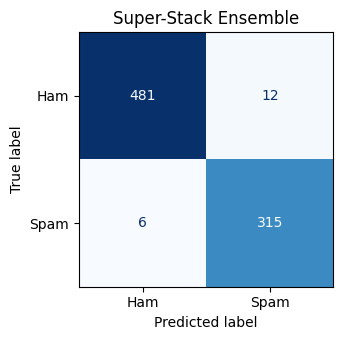

Saved → nb13_figures/nb13_superstack_cm.png
Saved → nb13_results.csv


In [16]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
print('\n=== Results Summary ===')
print(df_res.to_string(index=False))

print('\n=== Comparison Summary ===')
print(f'Corpus size  : {X_clean.shape[0]} rows  (removed {mislabeled_mask.sum()} atypical, kept {ambiguous_mask.sum()} borderline)')
ss = results[-1]
print(f'Super-Stack  : Acc={ss["Accuracy"]:.4f}  F1={ss["F1"]:.4f}  '
      f'AUC={ss["AUC"]:.4f}  MCC={ss["MCC"]:.4f}  FP={ss["FP"]}  FN={ss["FN"]}')

# Confusion matrix — Blues colormap
cm = confusion_matrix(y_test, results[-1]['_pred'])
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Super-Stack Ensemble')
plt.tight_layout()
plt.savefig('nb13_figures/nb13_superstack_cm.png', dpi=150)
plt.show()
print('Saved → nb13_figures/nb13_superstack_cm.png')

df_res.to_csv('nb13_results.csv', index=False)
print('Saved → nb13_results.csv')